# Predicting Diabetes from Health and Lifestyle Indicators

This notebook trains and compares Support Vector Machine classifiers (linear, RBF, and polynomial kernels) to predict diabetes status using demographic and lifestyle data from the 2022 National Health Interview Survey (NHIS) via IPUMS Health Surveys.


**Target:** `DIABETICEV` (whether respondent has ever been diagnosed with diabetes)

**Predictors:** BMI, age, physical activity (moderate and vigorous), sleep duration, soda consumption, income-to-poverty ratio, sex

In [2]:
# ====================================================================
# IMPORTS AND DATA LOAD
# ====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report, confusion_matrix
)

# Update path to wherever the NHIS CSV is stored in your Colab session
df = pd.read_csv('nhis_2022.csv')

print(f"Raw shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Raw shape: (35115, 48)
Columns: ['YEAR', 'SERIAL', 'STRATA', 'PSU', 'NHISHID', 'REGION', 'PERNUM', 'NHISPID', 'HHX', 'SAMPWEIGHT', 'ASTATFLG', 'CSTATFLG', 'AGE', 'SEX', 'MARSTCUR', 'EDUC', 'HOURSWRK', 'POVERTY', 'HEIGHT', 'WEIGHT', 'BMICALC', 'HINOTCOVE', 'CANCEREV', 'CHEARTDIEV', 'DIABETICEV', 'HEARTATTEV', 'STROKEV', 'ALCANYNO', 'ALCDAYSYR', 'CIGDAYMO', 'MOD10DMIN', 'VIG10DMIN', 'FRUTNO', 'VEGENO', 'JUICEMNO', 'SALADSNO', 'BEANNO', 'SALSAMNO', 'TOMSAUCEMNO', 'SODAPNO', 'FRIESPNO', 'SPORDRMNO', 'FRTDRINKMNO', 'COFETEAMNO', 'POTATONO', 'PIZZANO', 'HRSLEEP', 'CVDSHT']


## Data Cleaning

NHIS uses numeric codes for missing/refused/not-in-universe responses (typically 996-999, 97-99). Each variable has its own code conventions, verified against the NHIS 2022 codebook before cleaning.

Cleaning decisions:
- **Adults only**: filter to ages 18-85 (85 is a topcode for "85+")
- **Disease target**: recode `DIABETICEV` from {1=No, 2=Yes} to {0, 1}; drop unknowns
- **Continuous predictors**: replace special codes with NaN, then drop incomplete cases
- **POVERTY**: map ordinal codes to midpoint income-to-poverty ratios for true continuous interpretation
- **SEX**: recode to a binary `MALE` indicator
- **HRSLEEP code 25** ("less than 1 hour") recoded to 0.5 instead of dropped

In [3]:
# ====================================================================
# DATA CLEANING
# ====================================================================

# --- Step 1: Filter to adults with valid age ---
# AGE codes: 85 = "85 or older" (topcode, valid), 997/998/999 = unknowns
df_adult = df[df['AGE'].between(18, 85)].copy()

# --- Step 2: Clean diabetes target ---
# DIABETICEV: 1=No, 2=Yes, 7/9=Unknown
df_adult['diabetes'] = df_adult['DIABETICEV'].where(
    df_adult['DIABETICEV'].isin([1, 2])
).map({1: 0, 2: 1})
df_adult = df_adult.dropna(subset=['diabetes']).copy()
df_adult['diabetes'] = df_adult['diabetes'].astype(int)

# --- Step 3: Replace special codes in predictors with NaN ---
# Codes verified against NHIS 2022 codebook
special_codes = {
    'BMICALC':   [0, 996],                     # 0=NIU, 996=not calculable
    'MOD10DMIN': [996, 997, 998, 999],         # 996=extreme, others=unknown
    'VIG10DMIN': [996, 997, 998, 999],         # same
    'HRSLEEP':   [0, 97, 98, 99],              # 0=NIU, 97-99=unknowns
    'SODAPNO':   [996, 997, 998, 999],         # 996=NIU, others=unknown
    'SEX':       [7, 9],                        # unknowns
}
for col, codes in special_codes.items():
    df_adult[col] = df_adult[col].where(~df_adult[col].isin(codes), np.nan)

# --- Step 4: Variable-specific recodes ---
# HRSLEEP code 25 = "less than 1 hour", treat as 0.5 hours rather than dropping
df_adult['HRSLEEP'] = df_adult['HRSLEEP'].replace(25, 0.5)

# SEX: 1=Male, 2=Female. Convert to binary MALE indicator
df_adult['MALE'] = (df_adult['SEX'] == 1).astype(int)

# POVERTY: map ordinal codes to midpoint income-to-poverty ratios
# Codes from NHIS codebook: 11-14 = under 1.0x, 21-25 = 1.0-1.99x, 31-37 = 2.0-5.0+x
poverty_map = {
    10: 0.5, 11: 0.25, 12: 0.62, 13: 0.87, 14: 0.5,    # under 1.0x poverty
    20: 1.5, 21: 1.12, 22: 1.37, 23: 1.62, 24: 1.87, 25: 1.5,  # 1.0-1.99x
    30: 3.5, 31: 2.25, 32: 2.75, 33: 3.25, 34: 3.75,   # 2.0+x
    35: 4.25, 36: 4.75, 37: 5.0, 38: 3.5,
    98: np.nan, 99: np.nan                              # undefinable, unknown
}
df_adult['POVERTY_RATIO'] = df_adult['POVERTY'].map(poverty_map)

# --- Step 5: Final feature list and complete-case sample ---
predictors = ['BMICALC', 'AGE', 'MOD10DMIN', 'VIG10DMIN',
              'HRSLEEP', 'SODAPNO', 'POVERTY_RATIO', 'MALE']

model_df = df_adult.dropna(subset=predictors + ['diabetes']).copy()

print(f"Modeling sample: {model_df.shape}")
print(f"Diabetes prevalence: {model_df['diabetes'].mean():.1%}")
print(f"\nFeature summary:")
print(model_df[predictors].describe().round(2))

Modeling sample: (24109, 51)
Diabetes prevalence: 10.4%

Feature summary:
        BMICALC       AGE  MOD10DMIN  VIG10DMIN   HRSLEEP   SODAPNO  \
count  24109.00  24109.00   24109.00   24109.00  24109.00  24109.00   
mean      27.96     53.11      43.06      20.65      7.13      1.78   
std        5.54     18.37      59.81      42.69      1.38      4.70   
min       14.80     18.00       0.00       0.00      1.00      0.00   
25%       23.80     37.00       0.00       0.00      6.00      0.00   
50%       27.20     55.00      30.00       0.00      7.00      0.00   
75%       31.20     68.00      60.00      30.00      8.00      2.00   
max       52.70     85.00     720.00     720.00     24.00    240.00   

       POVERTY_RATIO      MALE  
count       24109.00  24109.00  
mean            3.35      0.46  
std             1.58      0.50  
min             0.25      0.00  
25%             1.87      0.00  
50%             3.75      0.00  
75%             5.00      1.00  
max             5.00  

## Exploratory Comparison: Predictors by Diabetes Status

A quick look at how predictors differ between cases and controls. Strong signals from age, BMI, and physical activity. Sleep and sex show essentially no marginal difference. Soda consumption appears slightly lower in diabetics, likely reflecting reverse causation (diet changes after diagnosis), a limitation of cross-sectional data.

Predictor means by diabetes status:
               No diabetes  Diabetes  Difference
BMICALC              27.63     30.78        3.15
AGE                  51.74     65.01       13.27
MOD10DMIN            44.55     30.09      -14.46
VIG10DMIN            21.93      9.57      -12.36
HRSLEEP               7.13      7.18        0.05
SODAPNO               1.83      1.41       -0.42
POVERTY_RATIO         3.40      2.91       -0.49
MALE                  0.46      0.49        0.03


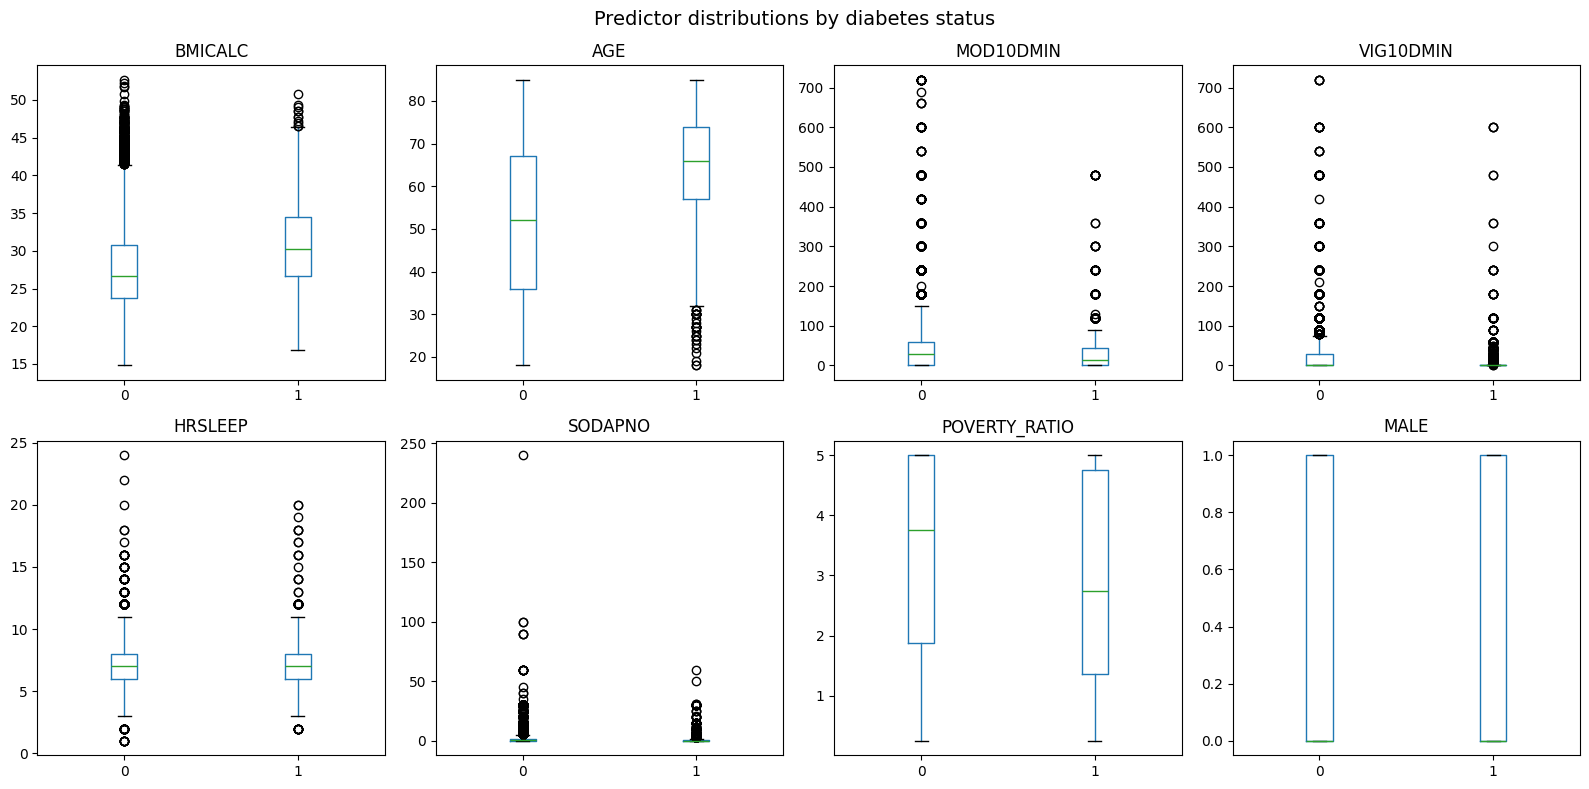

In [4]:
# ====================================================================
# EXPLORATORY DATA ANALYSIS
# ====================================================================
comparison = model_df.groupby('diabetes')[predictors].mean().round(2).T
comparison.columns = ['No diabetes', 'Diabetes']
comparison['Difference'] = comparison['Diabetes'] - comparison['No diabetes']
print("Predictor means by diabetes status:")
print(comparison)

# Boxplots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, predictors):
    model_df.boxplot(column=col, by='diabetes', ax=ax, grid=False)
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Predictor distributions by diabetes status', fontsize=14)
plt.tight_layout()
plt.savefig('predictor_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Train/Test Split and Standardization

80/20 stratified split to preserve the 10.4% diabetes prevalence in both sets. Features are standardized (zero mean, unit variance) using parameters fit on the training set only, then applied to the test set, this prevents test-set information from leaking into the scaling.


In [5]:
# ====================================================================
# TRAIN/TEST SPLIT AND STANDARDIZATION
# ====================================================================
X = model_df[predictors].values
y = model_df['diabetes'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}, prevalence: {y_train.mean():.1%}")
print(f"Test:  {X_test_s.shape}, prevalence: {y_test.mean():.1%}")

Train: (19287, 8), prevalence: 10.4%
Test:  (4822, 8), prevalence: 10.3%


## Model Tuning via Cross-Validation

Three SVM kernels are tuned via 3-fold cross-validation on the training set, with ROC-AUC as the scoring metric (preferred over accuracy at this prevalence level, where predicting "no diabetes" for everyone would yield 90% accuracy with zero clinical value).

`class_weight='balanced'` automatically reweights the loss function to compensate for the 10:1 class imbalance, encouraging the model to learn meaningful patterns for the minority class rather than defaulting to majority-class prediction.

**A note on the C parameter:** scikit-learn's C parameter is the inverse of the "C as budget for margin violations" formulation common in textbooks (including ISLR2). In sklearn, larger C means a stronger misclassification penalty and a narrower margin.

In [6]:
# ====================================================================
# MODEL TUNING (3-fold CV, scoring = ROC-AUC)
# ====================================================================

# --- Linear kernel ---
print("Tuning linear SVM...")
start = time.time()
linear_search = GridSearchCV(
    SVC(kernel='linear', class_weight='balanced', random_state=42),
    param_grid={'C': [0.1, 1, 10]},
    cv=3, scoring='roc_auc', n_jobs=-1
)
linear_search.fit(X_train_s, y_train)
print(f"  Best C: {linear_search.best_params_['C']}, "
      f"CV AUC: {linear_search.best_score_:.4f}, "
      f"Time: {time.time() - start:.1f}s")

# --- RBF kernel ---
print("\nTuning RBF SVM...")
start = time.time()
rbf_search = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', random_state=42),
    param_grid={'C': [0.5, 1, 2], 'gamma': [0.005, 0.01, 0.02]},
    cv=3, scoring='roc_auc', n_jobs=-1
)
rbf_search.fit(X_train_s, y_train)
print(f"  Best params: {rbf_search.best_params_}, "
      f"CV AUC: {rbf_search.best_score_:.4f}, "
      f"Time: {time.time() - start:.1f}s")

# --- Polynomial kernel ---
print("\nTuning polynomial SVM...")
start = time.time()
poly_search = GridSearchCV(
    SVC(kernel='poly', class_weight='balanced', coef0=1, random_state=42),
    param_grid={'C': [0.1, 1, 10], 'degree': [2, 3], 'gamma': ['scale', 0.01]},
    cv=3, scoring='roc_auc', n_jobs=-1
)
poly_search.fit(X_train_s, y_train)
print(f"  Best params: {poly_search.best_params_}, "
      f"CV AUC: {poly_search.best_score_:.4f}, "
      f"Time: {time.time() - start:.1f}s")

Tuning linear SVM...
  Best C: 1, CV AUC: 0.7778, Time: 166.3s

Tuning RBF SVM...
  Best params: {'C': 1, 'gamma': 0.01}, CV AUC: 0.7859, Time: 251.4s

Tuning polynomial SVM...
  Best params: {'C': 1, 'degree': 3, 'gamma': 0.01}, CV AUC: 0.7859, Time: 342.4s


## Test-Set Evaluation

The tuned models are evaluated on the held-out test set. ROC curves and AUC values measure ranking performance independent of any specific decision threshold; classification reports show precision/recall at the default 0.5 threshold (which, with `class_weight='balanced'`, favors recall on the minority class, appropriate for a screening application).


=== Linear kernel ===
Test AUC: 0.7818
              precision    recall  f1-score   support

 No diabetes       0.96      0.63      0.76      4323
    Diabetes       0.20      0.78      0.32       499

    accuracy                           0.65      4822
   macro avg       0.58      0.71      0.54      4822
weighted avg       0.88      0.65      0.72      4822


=== RBF kernel ===
Test AUC: 0.7894
              precision    recall  f1-score   support

 No diabetes       0.97      0.63      0.76      4323
    Diabetes       0.20      0.80      0.32       499

    accuracy                           0.64      4822
   macro avg       0.58      0.71      0.54      4822
weighted avg       0.89      0.64      0.71      4822


=== Polynomial kernel ===
Test AUC: 0.7898
              precision    recall  f1-score   support

 No diabetes       0.97      0.62      0.75      4323
    Diabetes       0.20      0.81      0.32       499

    accuracy                           0.64      4822
   macr

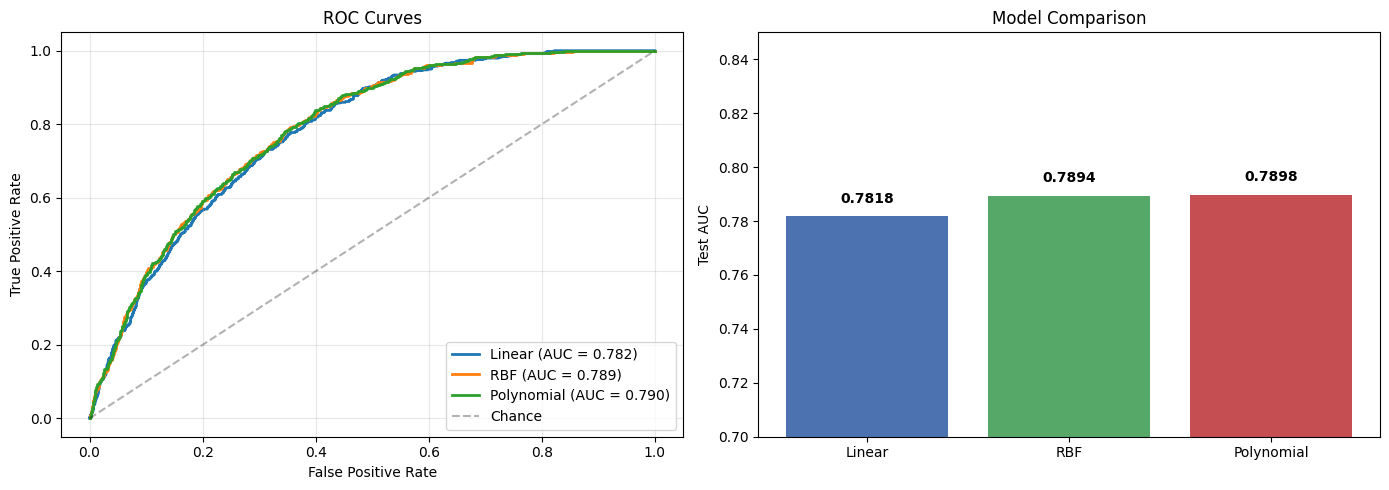

In [9]:
# ====================================================================
# FINAL EVALUATION ON TEST SET
# ====================================================================

# Refit with probability=True for ROC curves
final_models = {
    'Linear': SVC(kernel='linear', C=linear_search.best_params_['C'],
                  class_weight='balanced', probability=True, random_state=42),
    'RBF': SVC(kernel='rbf', C=rbf_search.best_params_['C'],
               gamma=rbf_search.best_params_['gamma'],
               class_weight='balanced', probability=True, random_state=42),
    'Polynomial': SVC(kernel='poly', C=poly_search.best_params_['C'],
                      degree=poly_search.best_params_['degree'],
                      gamma=poly_search.best_params_['gamma'], coef0=1,
                      class_weight='balanced', probability=True, random_state=42),
}

results = {}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, model in final_models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    results[name] = auc

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

    print(f"\n=== {name} kernel ===")
    print(f"Test AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred,
                                target_names=['No diabetes', 'Diabetes']))

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Chance')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

axes[1].bar(list(results.keys()), list(results.values()),
            color=['#4C72B0', '#55A868', '#C44E52'])
axes[1].set_ylabel('Test AUC')
axes[1].set_title('Model Comparison')
axes[1].set_ylim([0.7, 0.85])
for i, (name, auc) in enumerate(results.items()):
    axes[1].text(i, auc + 0.005, f'{auc:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Decision Boundary Visualization

To visualize how each kernel partitions the feature space, models are refit using just AGE and BMI, the two strongest individual predictors. The plots show the actual training data colored by class and the decision boundary each kernel learns. The linear kernel produces a single straight cut; RBF and polynomial kernels produce smooth curved boundaries that capture interactions between age and BMI.

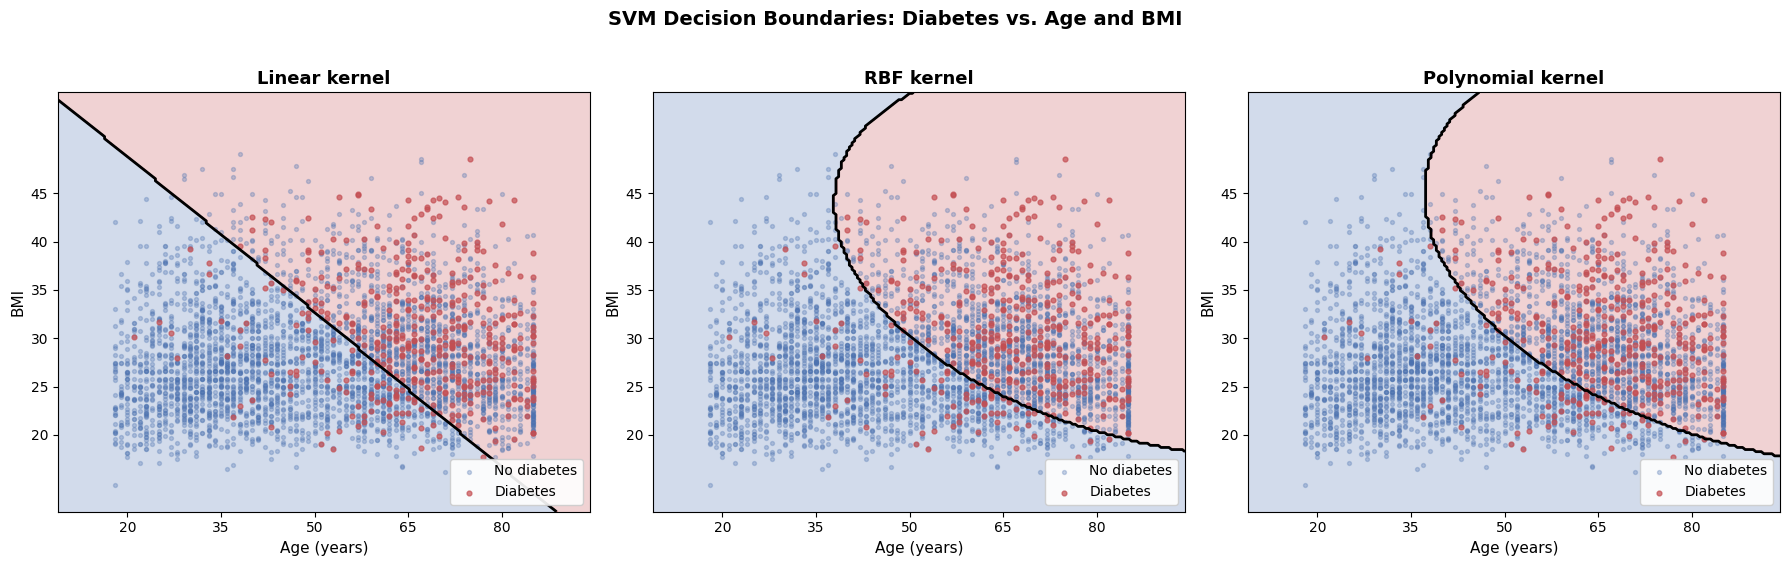

In [8]:
# ====================================================================
# DECISION BOUNDARY VISUALIZATION (2 strongest predictors)
# ====================================================================
viz_features = ['AGE', 'BMICALC']
X_viz = model_df[viz_features].values
y_viz = model_df['diabetes'].values

X_viz_train, X_viz_test, y_viz_train, y_viz_test = train_test_split(
    X_viz, y_viz, test_size=0.2, stratify=y_viz, random_state=42
)

scaler_viz = StandardScaler()
X_viz_train_s = scaler_viz.fit_transform(X_viz_train)

viz_models = {
    'Linear': SVC(kernel='linear', C=1, class_weight='balanced', random_state=42),
    'RBF': SVC(kernel='rbf', C=1, gamma=0.01, class_weight='balanced', random_state=42),
    'Polynomial': SVC(kernel='poly', C=1, degree=3, gamma=0.01, coef0=1,
                      class_weight='balanced', random_state=42)
}

# Grid for contour plotting
x_min, x_max = X_viz_train_s[:, 0].min() - 0.5, X_viz_train_s[:, 0].max() + 0.5
y_min, y_max = X_viz_train_s[:, 1].min() - 0.5, X_viz_train_s[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Subsample for plot legibility
np.random.seed(42)
idx = np.random.choice(len(X_viz_train_s), size=4000, replace=False)
X_plot = X_viz_train_s[idx]
y_plot = y_viz_train[idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, (name, model) in zip(axes, viz_models.items()):
    model.fit(X_viz_train_s, y_viz_train)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap=ListedColormap(['#4C72B0', '#C44E52']))
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)

    ax.scatter(X_plot[y_plot == 0, 0], X_plot[y_plot == 0, 1],
               c='#4C72B0', s=8, alpha=0.3, label='No diabetes')
    ax.scatter(X_plot[y_plot == 1, 0], X_plot[y_plot == 1, 1],
               c='#C44E52', s=12, alpha=0.7, label='Diabetes')

    age_ticks = scaler_viz.transform([[a, 30] for a in [20, 35, 50, 65, 80]])[:, 0]
    bmi_ticks = scaler_viz.transform([[50, b] for b in [20, 25, 30, 35, 40, 45]])[:, 1]
    ax.set_xticks(age_ticks); ax.set_xticklabels([20, 35, 50, 65, 80])
    ax.set_yticks(bmi_ticks); ax.set_yticklabels([20, 25, 30, 35, 40, 45])

    ax.set_xlabel('Age (years)', fontsize=11)
    ax.set_ylabel('BMI', fontsize=11)
    ax.set_title(f'{name} kernel', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', framealpha=0.9)

plt.suptitle('SVM Decision Boundaries: Diabetes vs. Age and BMI',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('decision_boundaries.png', dpi=200, bbox_inches='tight')
plt.show()

## Summary

Three SVM kernels were trained to classify diabetes status from health and lifestyle indicators in NHIS 2022 data. All three achieved comparable test-set performance (AUC 0.78-0.79), suggesting the underlying relationship is well-captured by smooth, near-linear decision surfaces with little benefit from added flexibility. AGE and BMI emerged as the dominant predictors, with physical activity providing additional discriminative signal. Sleep duration and sex showed no marginal predictive value at the population level.